## Univariate Linear Regression from Scratch with Salary Dataset


### Loading the dataset using Pandas


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

df_salary = pd.read_csv("Datasets/Salary_dataset.csv")
df_salary.head(3)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0


In [2]:
df_salary.drop(columns=["Unnamed: 0"], inplace=True)
df_salary.head(3)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0


### Inspecting the Data


In [3]:
df_salary.shape

(30, 2)

In [4]:
df_salary.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [5]:
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [6]:
df_salary.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [7]:
df_salary.dtypes

YearsExperience    float64
Salary             float64
dtype: object

### Plotting their distributions


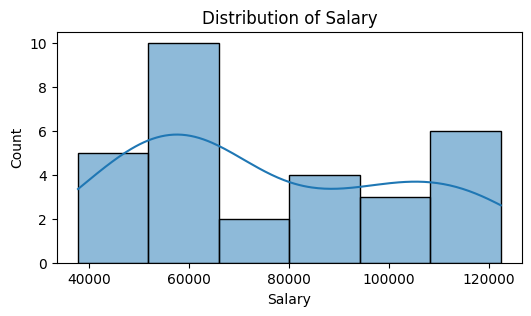

In [8]:
plt.figure(figsize=(6, 3))
sns.histplot(df_salary["Salary"], kde=True)
plt.title("Distribution of Salary")
plt.show()

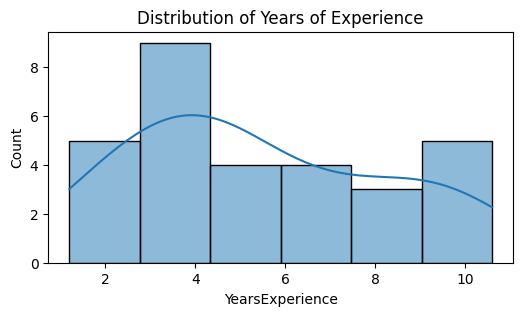

In [9]:
plt.figure(figsize=(6, 3))
sns.histplot(df_salary["YearsExperience"], kde=True)
plt.title("Distribution of Years of Experience")
plt.show()

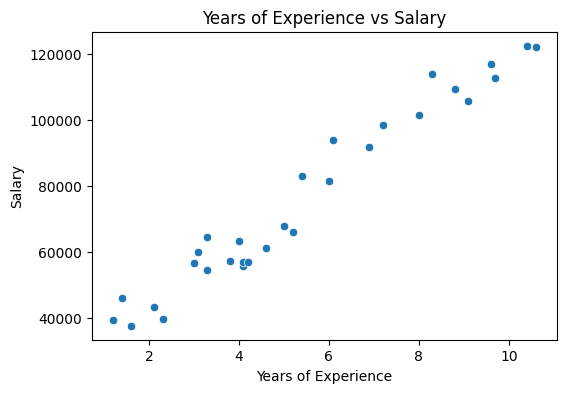

In [10]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="YearsExperience", y="Salary", data=df_salary)
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

Correlation Matrix:
                  YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


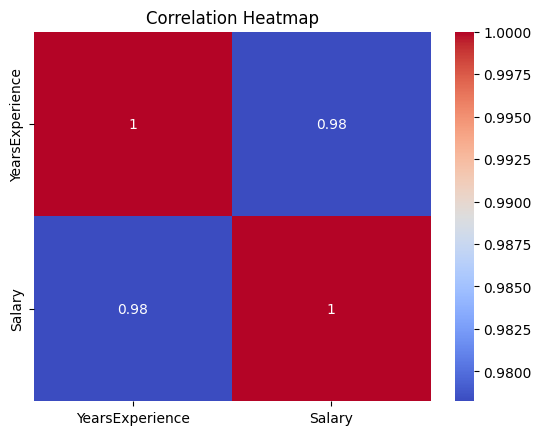

In [11]:
correlation = df_salary.corr()
print("Correlation Matrix:\n", correlation)

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

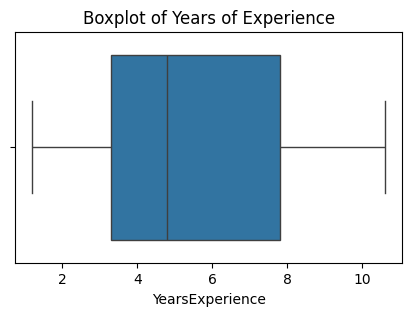

In [12]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df_salary["YearsExperience"])
plt.title("Boxplot of Years of Experience")
plt.show()

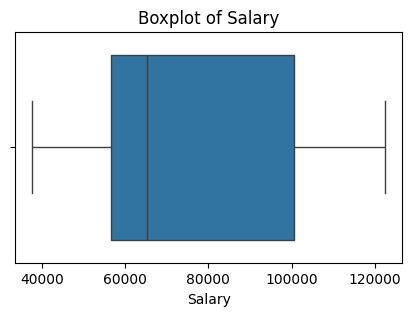

In [13]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df_salary["Salary"])
plt.title("Boxplot of Salary")
plt.show()

Boxplot shows salary data is slightly right skewed, since it is our target we require no transformation right now!


In [14]:
# Splitting the data
X = df_salary[["YearsExperience"]].values
y = df_salary[["Salary"]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X Train Shape: {X_train.shape}\ny Train Shape: {y_train.shape}")
print(f"X Test Shape: {X_test.shape}\ny Test Shape: {y_test.shape}")

X Train Shape: (24, 1)
y Train Shape: (24, 1)
X Test Shape: (6, 1)
y Test Shape: (6, 1)


In [15]:
# Normalize features for Gradient Descent Convergence 
X_mean, X_std = X_train.mean(), X_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

X_train_norm = (X_train - X_mean) / X_std
y_train_norm = (y_train - y_mean) / y_std

# Prevent Dataleakage
X_test_norm = (X_test - X_mean) / X_std
y_test_norm = (y_test - y_mean) / y_std

In [16]:
class UnivariateLinearRegressor:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.loss_history = []
        
    def _mse_loss(self, y_pred, y):
        m = y.shape[0]
        return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    
    def _gradient_descent(self, X, y, y_pred):
        m = y.shape[0]
        d_theta0 = np.sum(y_pred - y) / m
        d_theta1 = np.sum((y_pred - y) * X[:, 1].reshape(-1, 1)) / m
        return np.array([[d_theta0], [d_theta1]])
    
    def fit(self, X, y):
        # Add intercept term
        X_b = np.hstack((np.ones((X.shape[0], 1)), X))  # shape (n_samples, 2)
        self.theta = np.zeros((2, 1))
        
        for i in range(self.n_iters):
            y_pred = X_b @ self.theta
            loss = self._mse_loss(y_pred, y)
            self.loss_history.append(loss)
            
            gradients = self._gradient_descent(X_b, y, y_pred)
            self.theta -= self.learning_rate * gradients
            
            if i % 50 == 0:
                print(f"Iteration {i}: MSE Loss = {loss:.4f}")
        
        return self.theta
    
    def predict(self, X):
        X_b = np.hstack((np.ones((X.shape[0], 1)), X))
        return X_b @ self.theta


In [17]:
model = UnivariateLinearRegressor(learning_rate=0.01, n_iters=500)
model.fit(X_train_norm, y_train_norm)

Iteration 0: MSE Loss = 0.5000
Iteration 50: MSE Loss = 0.1943
Iteration 100: MSE Loss = 0.0823
Iteration 150: MSE Loss = 0.0414
Iteration 200: MSE Loss = 0.0264
Iteration 250: MSE Loss = 0.0209
Iteration 300: MSE Loss = 0.0189
Iteration 350: MSE Loss = 0.0182
Iteration 400: MSE Loss = 0.0179
Iteration 450: MSE Loss = 0.0178


array([[2.16123415e-16],
       [9.75657116e-01]])

In [18]:
y_pred_test = model.predict(X_test_norm)
y_pred_test = y_pred_test * y_std + y_mean

In [19]:
print("Predictions on test set:")
for pred, actual in zip(y_pred_test.flatten(), y_test.flatten()):
    print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")


Predictions on test set:
Predicted: 115517.99, Actual: 112636.00
Predicted: 71517.08, Actual: 67939.00
Predicted: 102411.34, Actual: 113813.00
Predicted: 75261.84, Actual: 83089.00
Predicted: 55601.86, Actual: 64446.00
Predicted: 60282.80, Actual: 57190.00


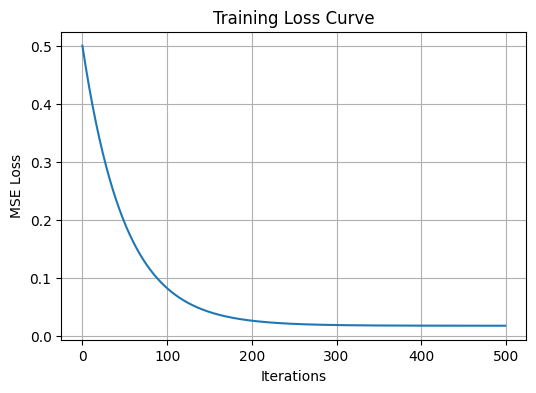

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


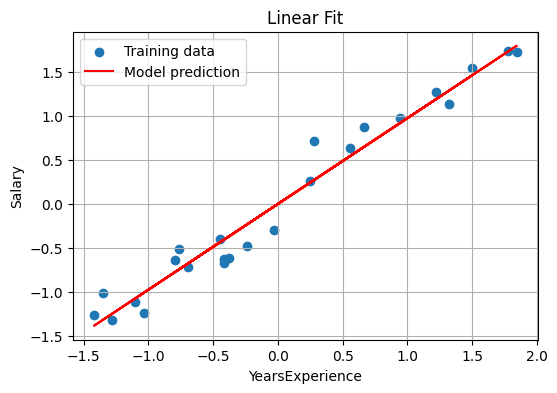

In [21]:
plt.figure(figsize=(6, 4))
plt.scatter(X_train_norm, y_train_norm, label="Training data")
plt.plot(X_train_norm, model.predict(X_train_norm), color='red', label="Model prediction")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Linear Fit")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
y_true_scr = y_test_norm
y_pred_scr = model.predict(X_test_norm)
y_true_scr, y_pred_scr

(array([[ 1.38997327],
        [-0.22678133],
        [ 1.43254705],
        [ 0.3212159 ],
        [-0.35312815],
        [-0.61558808]]),
 array([[ 1.49421907],
        [-0.09735705],
        [ 1.02013257],
        [ 0.03809624],
        [-0.67303352],
        [-0.50371691]]))

In [23]:
# Other metrics

def evaluate_metrics(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mse = np.mean((y_true - y_pred) ** 2)

    rmse = np.sqrt(mse)

    mae = np.mean(np.abs(y_true - y_pred))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    median_ae = np.median(np.abs(y_true - y_pred))

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "Median AE": median_ae
    }

evaluate_metrics(y_true=y_true_scr, y_pred=y_pred_scr)

{'MSE': np.float64(0.06545248074759939),
 'RMSE': np.float64(0.2558368244557444),
 'MAE': np.float64(0.22683012712122474),
 'R2': np.float64(0.9020629066844771),
 'MAPE': np.float64(48.37728748041872),
 'Median AE': np.float64(0.20627197170573)}

### Using SkLearn

In [24]:
from sklearn.linear_model import LinearRegression

model_sk = LinearRegression()
model_sk.fit(X_train, y_train)
y_pred_sk = model_sk.predict(X_test)


In [25]:
comparison_df = pd.DataFrame({
    "YearsExperience": X_test.flatten(),
    "Actual Values": y_test.flatten(),
    "Scratch Prediction": y_pred_test.flatten(),
    "Sklearn Prediction": y_pred_sk.flatten()
})

print(comparison_df)

   YearsExperience  Actual Values  Scratch Prediction  Sklearn Prediction
0              9.7       112636.0       115517.992443       115791.210113
1              5.0        67939.0        71517.079813        71499.278095
2              8.3       113813.0       102411.337617       102597.868661
3              5.4        83089.0        75261.838334        75268.804224
4              3.3        64446.0        55601.856095        55478.792045
5              3.8        57190.0        60282.804247        60190.699707


In [26]:
# Metric Evaluation for SkLearn method
y_true_sk = y_test_norm
y_pred_sk = (model_sk.predict(X_test) - y_mean) / y_std

evaluate_metrics(y_true_sk, y_pred_sk)

{'MSE': np.float64(0.06519633652827417),
 'RMSE': np.float64(0.2553357329640216),
 'MAE': np.float64(0.2273900520519275),
 'R2': np.float64(0.9024461774180498),
 'MAPE': np.float64(48.476787287830355),
 'Median AE': np.float64(0.2058240317611679)}

In [27]:
compare_scr_sk = pd.DataFrame({
    "SkLearn Metrics": evaluate_metrics(y_true_sk, y_pred_sk),
    "Scratch Metrics": evaluate_metrics(y_true=y_true_scr, y_pred=y_pred_scr)
})

compare_scr_sk

,SkLearn Metrics,Scratch Metrics
MSE,0.065196,0.065452
RMSE,0.255336,0.255837
MAE,0.227390,0.226830
R2,0.902446,0.902063
MAPE,48.476787,48.377287
Median AE,0.205824,0.206272
